In [137]:
%run 0_config_plot.ipynb
%run 0_config_nets.ipynb

In [139]:
e1 = []; e2 = []; j1 = []; j2 = []; r1 = []; r2 = []; p1 = []; p2 = []; 
for it in its:
    print(ll,',',it)
    trained_params_list              = [];  parameters_list = []; iii = []; 
    tFe = 0;  net = tnet; 
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy1,e_path1         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy1,j_out1         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy1,r_out1, paths1  = run_net (tFe,ll,it,True,1, net)  

    print(it)
    tFe = 1; net = tnet; 
    trained_params_list              = [];  parameters_list = []; iii = []; 
    exact_gs_energy2,e_path2         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy2,j_out2         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy2,r_out2, paths2  = run_net (tFe,ll,it,True,1, net)  

    l = ll; l_info = [];  l_info.append(upper(tnet));  l_info.append(upper(tnet)) 
    str_nets = '1_' + upper(tnet)
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2

    plot2(e_path1,e_path2,
            j_out1,r_out1,
            j_out2,r_out2,
            l,it,l_info,
            x_pos, y_pos, str_nets)
        
    plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,0)
    plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,1)

    plot_distributions(paths1, paths2,  0, -1,ll,it, str_nets)
    plotpca(paths1, paths2,  0, -1, ll,it, str_nets)
    plotpca3(paths1, paths2,  0, -1, ll,it, str_nets) 

    e1.append(e_path1); e2.append(e_path2)
    j1.append(j_out1); j2.append(j_out2)   
    r1.append(r_out1); r2.append(r_out2)           
    p1.append(paths1); p2.append(paths2)

12 , 60


  0%|                                                              | 0/60 [00:00<?, ?it/s]

nffnn


  0%|                                                              | 0/60 [00:00<?, ?it/s]

60


  0%|                                                              | 0/60 [00:00<?, ?it/s]

nffnn


  0%|                                                              | 0/60 [00:00<?, ?it/s]

fig/fff/EGS_L_12_12_IT_60_NFFNN.png
Figura salva em: fig/fff/PRSN_12_12_IT_60_1_NFFNN_0.png
Figura salva em: fig/fff/PRSN_12_12_IT_60_1_NFFNN_1.png
Figura salva como fig/fff/NDP_12_12_IT_60_1_NFFNN.png
Figure saved to fig/fff/PCA_12_12_IT_60_1_NFFNN.png
Figure saved to fig/fff/PCA3D_12_12_IT_60_1_NFFNN.png


In [147]:
p1[0][2],p2[0][2],

('dataf/ffnn2_12_0_60_kernel_real.csv', 'dataf/ffnn2_12_1_60_kernel_real.csv')

In [148]:
df = pd.read_csv(p2[0][2])
len(df)

60

nffnn
fig/fff/EGS_L_12_12_IT_60_N.png


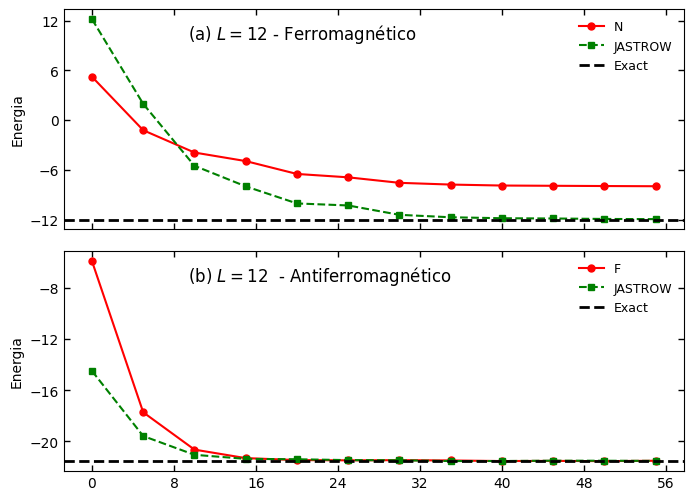

In [149]:
%run 0_config_plot.ipynb
x_pos  = 0.2 ;  y_pos = 0.94;
print(tnet)
plot2(e1[0],e2[0],j1[0],r1[0],j2[0],r2[0],
              ll,its[0],tnet,x_pos, y_pos, tnet, True)

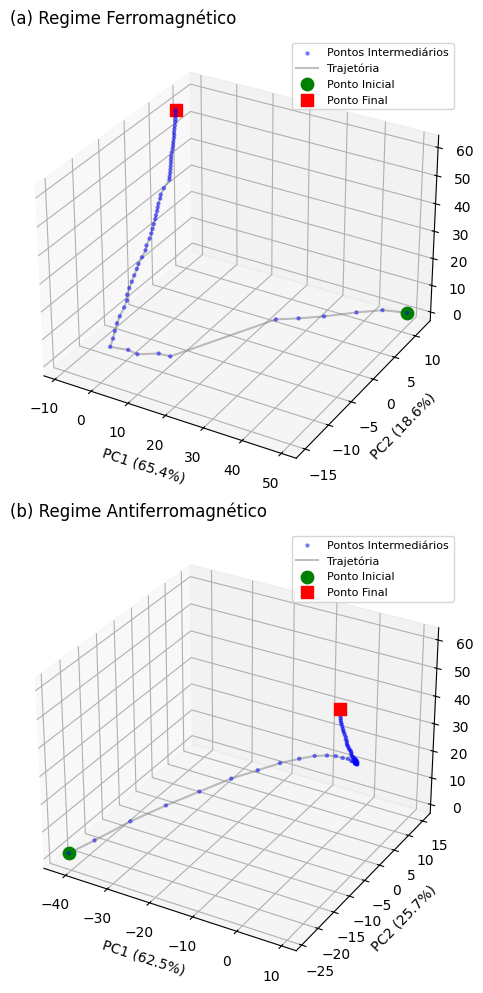

Figure saved to fig/fff/PCA3D_12_12_IT_60_nffnn.png


In [151]:
%run 0_config_plot.ipynb
plotpca3(p1[0], p2[0], 0, -1, ll, 60, tnet, True)

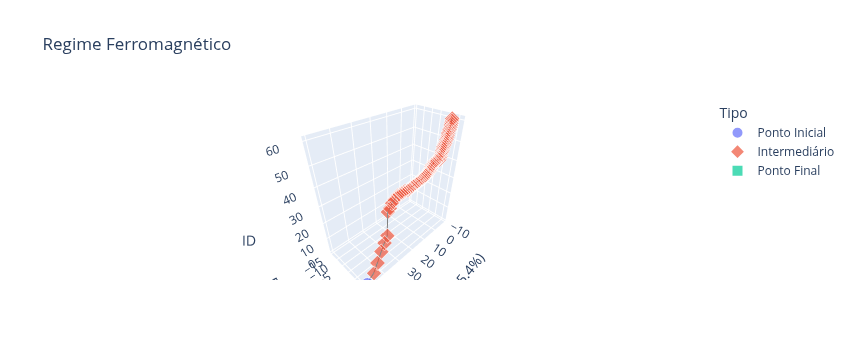

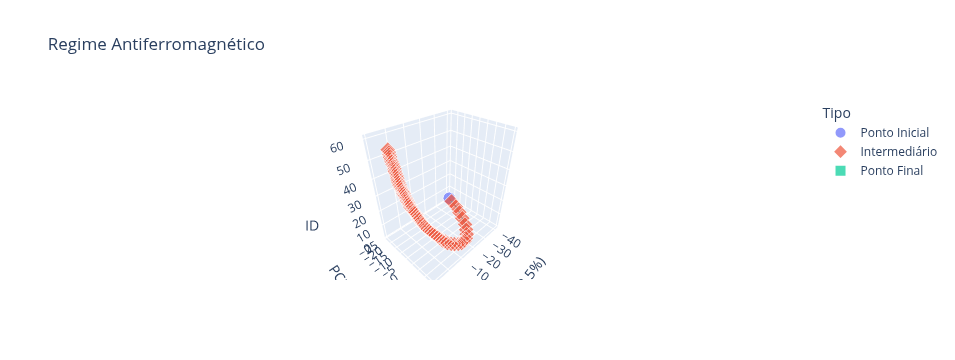

In [154]:
plot_pca_3d_interactive(p1[0][2], 0, -1, "Regime Ferromagnético")
plot_pca_3d_interactive(p2[0][2], 0, -1, "Regime Antiferromagnético")

def plotpca(paths1, paths2,initial_point_idx,last_point_idx):

    L                 = 12
    IT                = 60
    str_nets          = 'NFFNN'

    pathfg = "fig/pca/PCA_" + str(L) + "_" + str(L) + "_IT_" + str(IT) + "_"  + str_nets + ".png"

    print(pathfg)

    try:
        # Data loading and validation
        df1 = pd.read_csv(paths1[2])
        if df1.empty:
            raise ValueError("Dataframe 1 is empty")

        df2 = pd.read_csv(paths2[2])
        if df2.empty:
            raise ValueError("Dataframe 2 is empty")

        # Create figure with two subplots (vertical arrangement)
        fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
        
        # Process and plot first dataset (Ferromagnético)
        plot_pca(axs[0], df1, initial_point_idx, last_point_idx, 
                title='(a) Regime Ferromagnético',
                point_labels=['Ponto Inicial', 'Ponto Final'])
        
        # Process and plot second dataset (Antiferromagnético)
        plot_pca(axs[1], df2, initial_point_idx, last_point_idx,
                title='(b) Regime Antiferromagnético',
                point_labels=['Ponto Inicial', 'Ponto Final'])

        # Configurações finais do layout
        plt.subplots_adjust(hspace=0.3, wspace=0.1)  # Aumentei o hspace para 0.3
        plt.savefig(pathfg, dpi=300, bbox_inches='tight')
        plt.show()
        
        plt.close()
        print(f"Figure saved to {pathfg}")
        
    except Exception as e:
        print(f"Error in plot_dynamics: {str(e)}")
        raise

def plot_pca(ax, df, initial_point_idx, last_point_idx, title, point_labels):
    # Extract points
    all_points = df.iloc[:, 1:].values  # Todas as séries (sem a primeira coluna)
    print(all_points)

    # Trata valores ausentes (NaN) com média da coluna
    imputer = SimpleImputer(strategy="mean")
    all_points_imputed = imputer.fit_transform(all_points)

    # Padronização (zero média, desvio padrão 1)
    X_std = StandardScaler().fit_transform(all_points_imputed)

    # PCA
    n_components = min(2, X_std.shape[1])
    pca = PCA(n_components=n_components)
    principal_components = pca.fit_transform(X_std)

    # Distância Euclidiana entre o ponto inicial e final no espaço PCA
    distance = np.linalg.norm(
        principal_components[initial_point_idx] - principal_components[last_point_idx]
    )

    # Configurações do estilo do gráfico
    colors = ['green', 'red']
    mark = ['o', 's']
    line_style = 'grey'
    alpha = 0.3

    # Plot PCA Trajectory
    if n_components >= 2:
        # Full trajectory
        ax.scatter(principal_components[:, 0], principal_components[:, 1], 
                  alpha=alpha, color='blue', marker='.', label='Pontos Intermediários')
        ax.plot(principal_components[:, 0], principal_components[:, 1], 
               color=line_style, alpha=alpha, linestyle='-', label='Trajetória')

        print(initial_point_idx, last_point_idx)
        
        # Highlight points
        ax.scatter(principal_components[initial_point_idx, 0], 
                  principal_components[initial_point_idx, 1], 
                  color=colors[0], s=100, marker=mark[0], label=point_labels[0])
        ax.scatter(principal_components[last_point_idx, 0], 
                  principal_components[last_point_idx, 1], 
                  color=colors[1], s=100, marker=mark[1], label=point_labels[1])
        
        ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    else:
        # 1D case
        ax.scatter(principal_components[:, 0], np.zeros(len(principal_components)), 
                  alpha=alpha, color='blue', marker='.', label='Pontos Intermediários')
        ax.plot(principal_components[:, 0], np.zeros(len(principal_components)), 
               color=line_style, alpha=alpha, linestyle='-', label='Trajetória')
        ax.scatter(principal_components[initial_point_idx, 0], 0, 
                  color=colors[0], s=100, marker=mark[0], label=point_labels[0])
        ax.scatter(principal_components[last_point_idx, 0], 0, 
                  color=colors[1], s=100, marker=mark[1], label=point_labels[1])

    # Configurações do eixo
    ax.tick_params(direction='in', length=4, width=1.0, top=True, bottom=True, left=True, right=True)
    ax.tick_params(which='minor', direction='in', length=2, width=0.8, top=True, bottom=True, left=True, right=True)
    
    # Configurações dos labels
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    
    # Título e legenda
    ax.set_title(title, fontsize=12, loc='left', pad=10)
    ax.legend(fontsize=9, loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)  # Legenda fora
    ax.grid(alpha=0.3)
    
    # Ajusta o layout para acomodar a legenda
    plt.tight_layout(rect=[0, 0, 0.85, 1])  # Reduz a área útil em 15% à direita para a legenda

In [120]:
trained_params_list              = []; parameters_list = [];iii = []; 
g_run_cc_energy2,r_out2, paths2  = run_net (0,12,5,True,1, 'nffnn')

nffnn


  0%|                                                               | 0/5 [00:00<?, ?it/s]

In [121]:
paths2[2]

'dataf/ffnn2_12_0_5_kernel_real.csv'

In [122]:
df = pd.read_csv(paths2[2])
len(df)

5

In [67]:
its  = [60]
ll   = 12
tnet = 'nffnn'

In [127]:
e1,e2,j1,j2,r1,r2,p1,p2,ll,tnet,its  = run(ll,tnet, its)

12 , 60


  0%|                                                              | 0/60 [00:00<?, ?it/s]

nffnn


  0%|                                                              | 0/60 [00:00<?, ?it/s]

60


  0%|                                                              | 0/60 [00:00<?, ?it/s]

nffnn


  0%|                                                              | 0/60 [00:00<?, ?it/s]

fig/fff/EGS_L_12_12_IT_60_NFFNN.png
Figura salva em: fig/fff/PRSN_12_12_IT_60_1_NFFNN_0.png
Figura salva em: fig/fff/PRSN_12_12_IT_60_1_NFFNN_1.png
Figura salva como fig/fff/NDP_12_12_IT_60_1_NFFNN.png
Figure saved to fig/fff/PCA_12_12_IT_60_1_NFFNN.png
Figure saved to fig/fff/PCA3D_12_12_IT_60_1_NFFNN.png


In [128]:
e1,e2,j1,j2, r1, r2, p1, p2,ll, tnet, its

(['dataf/exact_12_0.csv'],
 ['dataf/exact_12_1.csv'],
 ['dataf/jastrow_12_0_60'],
 ['dataf/jastrow_12_1_60'],
 ['dataf/ffnn2_12_0_60'],
 ['dataf/ffnn2_12_1_60'],
 [['dataf/ffnn2_12_0_60_bias_real.csv',
   'dataf/ffnn2_12_0_60_bias_img.csv',
   'dataf/ffnn2_12_0_60_kernel_real.csv',
   'dataf/ffnn2_12_0_60_kernel_img.csv']],
 [['dataf/ffnn2_12_1_60_bias_real.csv',
   'dataf/ffnn2_12_1_60_bias_img.csv',
   'dataf/ffnn2_12_1_60_kernel_real.csv',
   'dataf/ffnn2_12_1_60_kernel_img.csv']],
 12,
 'nffnn',
 [60])

nffnn
fig/fff/EGS_L_12_12_IT_60_N.png


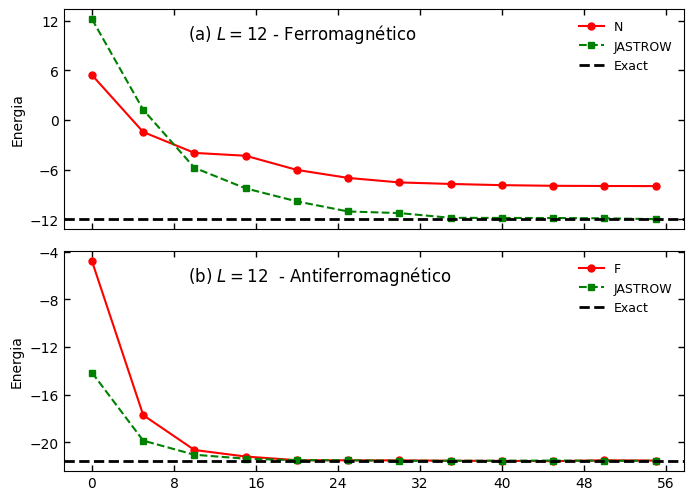

In [129]:
%run 0_config_plot.ipynb
x_pos  = 0.2 ;  y_pos = 0.94;
print(tnet)
plot2(e1[0],e2[0],j1[0],r1[0],j2[0],r2[0],
              ll,its[0],tnet,x_pos, y_pos, tnet, True)

In [133]:
df = pd.read_csv(p1[0][2])

In [134]:
len(df)

60

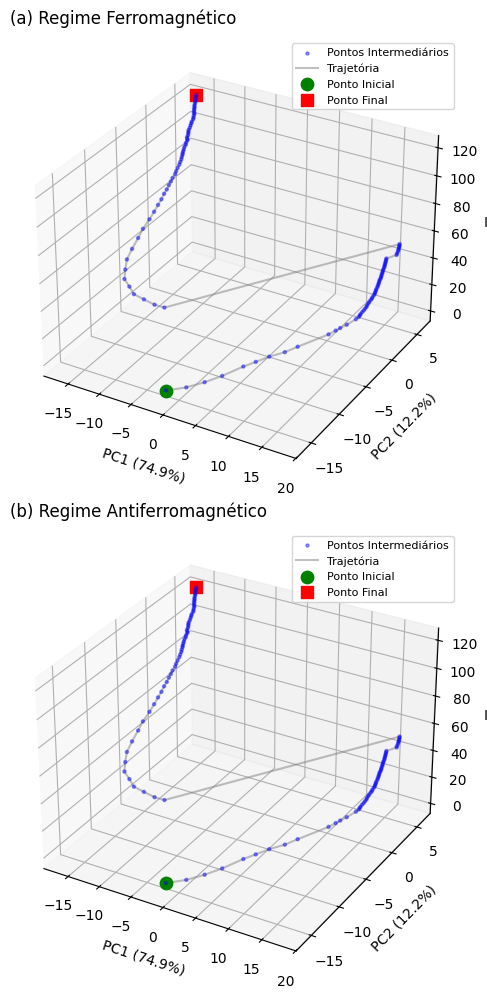

Figure saved to fig/fff/PCA3D_12_12_IT_60_nffnn.png


In [104]:
%run 0_config_plot.ipynb
plotpca3(p2[0], p2[0], 0, -1, ll, 60, tnet, True)

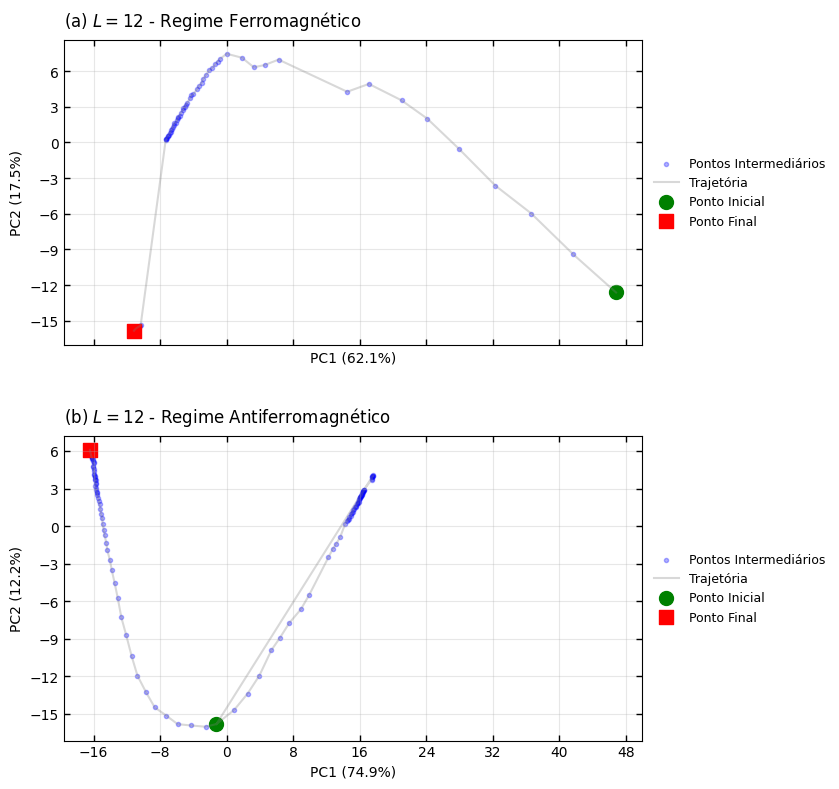

Figure saved to fig/fff/PCA_12_12_IT_60_nffnn.png


In [91]:
%run 0_config_plot.ipynb
plotpca(p1[0], p2[0], 0, -1, ll, 60, tnet, True)

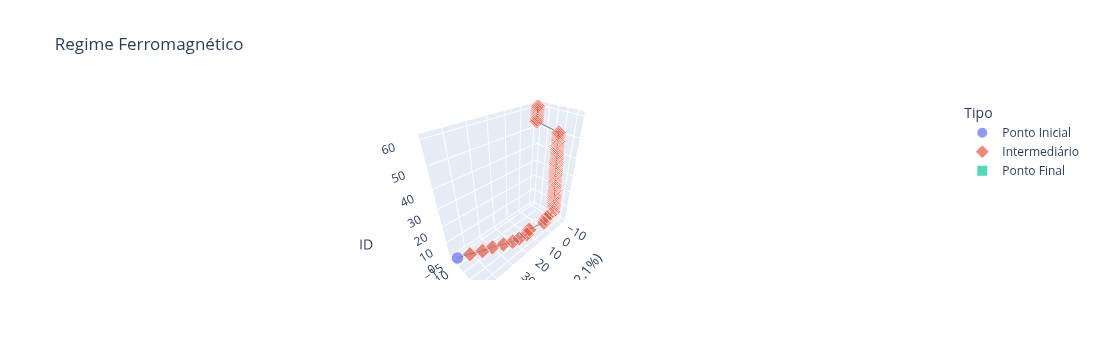

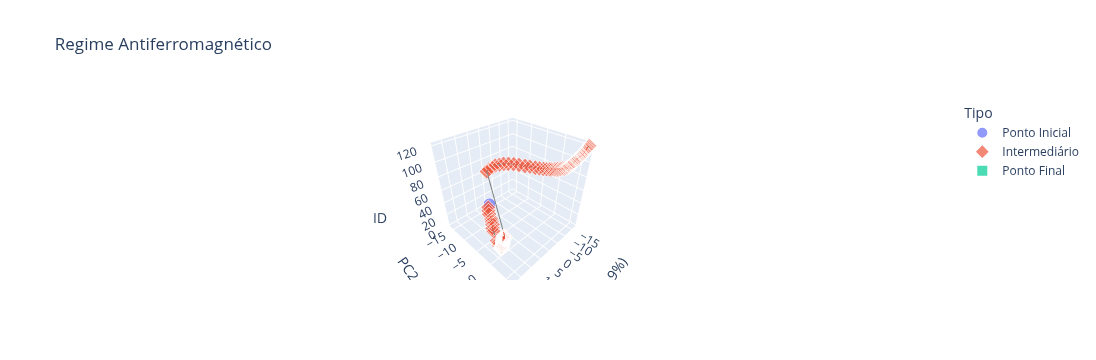

In [94]:
plot_pca_3d_interactive(p1[0][2], 0, -1, "Regime Ferromagnético")
plot_pca_3d_interactive(p2[0][2], 0, -1, "Regime Antiferromagnético")

In [33]:
pp1 = p1[0][2]

In [34]:
df1 = pd.read_csv(pp1)

In [40]:
288/12

24.0

In [39]:
df1.shape

(60, 289)

In [35]:
df1.head()

,id,0,1,2,3,4,5,6,7,8,...,278,279,280,281,282,283,284,285,286,287
0,1,0.165895,-0.224566,0.280211,-0.293083,-0.546607,0.426980,0.158670,-0.086084,0.166519,...,-0.496302,0.242712,-0.116637,0.310929,0.361338,-0.195591,0.519112,-0.291138,-0.363536,-0.155229
1,2,0.156890,-0.233000,0.284060,-0.300038,-0.580782,0.437571,0.159080,-0.085161,0.154600,...,-0.515922,0.249227,-0.121230,0.287673,0.344185,-0.198709,0.535446,-0.293069,-0.367858,-0.175646
2,3,0.158610,-0.225554,0.287973,-0.300123,-0.582432,0.439716,0.161984,-0.091679,0.152632,...,-0.543575,0.257515,-0.116252,0.267882,0.332455,-0.231771,0.545763,-0.303774,-0.368747,-0.183295
3,4,0.144124,-0.229238,0.276831,-0.312493,-0.601718,0.434162,0.166964,-0.064746,0.175299,...,-0.542593,0.267316,-0.109776,0.265139,0.322903,-0.246892,0.565905,-0.305243,-0.362134,-0.182177
4,5,0.136270,-0.229159,0.266892,-0.316653,-0.612600,0.430246,0.165381,-0.079738,0.185809,...,-0.563973,0.267901,-0.099605,0.256991,0.312416,-0.288062,0.602931,-0.325468,-0.367779,-0.192811


In [ ]:
its  = [30,40,50,60,70,80]
ll   = 12
tnet = 'nffnn'

In [ ]:
run(ll,tnet, its)

In [ ]:
its  = [10,20,30]
ll   = 6
tnet = 'nffnn'

run(ll,tnet, its)

In [ ]:
plot2(e_path1,e_path2,j_out1,r_out1,j_out2,r_out2,l,it,l_info,l_tp,x_pos, y_pos, str_nets)

In [ ]:
plot_pca_3d_interactive(paths1[2], 0, -1, "Regime Ferromagnético")
plot_pca_3d_interactive(paths2[2], 0, -1, "Regime Antiferromagnético")

In [ ]:
paths1

In [ ]:
plotpca(paths1, paths2,  0, -1, ll,it, str_nets)

In [ ]:
df1 = pd.read_csv(paths1[2])

In [ ]:
df1.columns

In [ ]:
for it in [40,50,60,70,80,100,120]:
    print(it)
    ll     = 22; tFe = 0;  net = 'nffnn';str_nets = '1_NFFNN'; l_info = ['NFFNN']
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy1,e_path1         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy1,j_out1         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy1,r_out1, paths1  = run_net (tFe,ll,it,True,1, net)  

    tFe = 1; net    = 'nffnn';str_nets = '1_NFFNN'; l_info = ['NFFNN']
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy2,e_path2         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy2,j_out2         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy2,r_out2, paths2  = run_net (tFe,ll,it,True,1, net)  

    l = ll; l_tp = ['NFFNN', 'NFFNN']; l_info =  ['NFFNN', 'NFFNN']
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2

    plot2(e_path1,e_path2,j_out1,r_out1,j_out2,r_out2,l,it,l_info,l_tp,x_pos, y_pos, str_nets)
    plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,0)
    plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,1)

    plot_distributions(paths1, paths2,  0, -1,ll,it, str_nets)
    plotpca(paths1, paths2,  0, -1, ll,it, str_nets)

In [ ]:
for it in [40,50,60,70,80]:
    print(it)
    ll     = 20; tFe = 0;  net = 'nffnn';str_nets = '1_NFFNN'; l_info = ['NFFNN']
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy1,e_path1         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy1,j_out1         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy1,r_out1, paths1  = run_net (tFe,ll,it,True,1, net)  

    tFe = 1; net    = 'nffnn';str_nets = '1_NFFNN'; l_info = ['NFFNN']
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy2,e_path2         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy2,j_out2         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy2,r_out2, paths2  = run_net (tFe,ll,it,True,1, net)  

    l = ll; l_tp = ['NFFNN', 'NFFNN']; l_info =  ['NFFNN', 'NFFNN']
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2

    plot2(e_path1,e_path2,j_out1,r_out1,j_out2,r_out2,l,it,l_info,l_tp,x_pos, y_pos, str_nets)
    plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,0)
    plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,1)

    plot_distributions(paths1, paths2,  0, -1,ll,it, str_nets)
    plotdp(paths1, paths2,  0, -1, ll,it, str_nets)

In [ ]:
%run 0_config_plot.ipynb
plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,1)

In [ ]:
for it in [40,50,60,70,80]:
    print(it)
    ll     = 6; tFe = 0;  net = 'nffnn';str_nets = '1_NFFNN'; l_info = ['NFFNN']
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy1,e_path1         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy1,j_out1         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy1,r_out1, paths1  = run_net (tFe,ll,it,True,1, net)  

    tFe = 1; net    = 'nffnn';str_nets = '1_NFFNN'; l_info = ['NFFNN']
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy2,e_path2         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy2,j_out2         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy2,r_out2, paths2  = run_net (tFe,ll,it,True,1, net)  

    l = ll; l_tp = ['NFFNN', 'NFFNN']; l_info =  ['NFFNN', 'NFFNN']
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2

    plot2(e_path1,e_path2,j_out1,r_out1,j_out2,r_out2,l,it,l_info,l_tp,x_pos, y_pos, str_nets)
    plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,0)
    plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,1)

    plot_distributions(paths1, paths2,  0, -1,ll,it, str_nets)
    plotdp(paths1, paths2,  0, -1, ll,it, str_nets)

In [ ]:
%run 0_config_plot.ipynb

plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,1)

In [ ]:
%run 0_config_plot.ipynb

plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,0)


In [ ]:
plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,1)

In [ ]:
L1     = [12];
it = 50; tFe = 0
net    = 'rbm';str_nets = '1_RBM'; l_info = ['RBM']
for ll in L1:
    print(ll)
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy1,e_path1         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy1,j_out1         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy1,r_out1, paths1  = run_net (tFe,ll,it,True,1, net)  


tFe = 1
net    = 'rbm';str_nets = '1_RBM'; l_info = ['RBM']
for ll in L1:
    print(ll)
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy2,e_path2         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy2,j_out2         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy2,r_out2, paths2  = run_net (tFe,ll,it,True,1, net)  

In [ ]:
l = L1[0]; l_tp = ['RBM', 'RBM']; l_info =  ['RBM', 'RBM']
plot2(e_path1,e_path2,j_out1,r_out1,j_out2,r_out2,l,it,l_info,l_tp,x_pos, y_pos, str_nets)

In [ ]:
%run 0_config_plot.ipynb
plot_pearson_neurons(paths1, paths2, -1, l[0],it, str_nets)

In [ ]:
L1     = [20];
it = 40; tFe = 0
net    = 'nffnn';str_nets = '1_NFFNN'; l_info = ['NFFNN']
for ll in L1:
    print(ll)
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy1,e_path1         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy1,j_out1         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy1,r_out1, paths1  = run_net (tFe,ll,it,True,1, net)  


tFe = 1
net    = 'nffnn';str_nets = '1_NFFNN'; l_info = ['NFFNN']
for ll in L1:
    print(ll)
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy2,e_path2         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy2,j_out2         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy2,r_out2, paths2  = run_net (tFe,ll,it,True,1, net)  

In [ ]:
l = L1[0]; l_tp = ['NFFNN', 'NFFNN']; l_info =  ['NFFNN', 'NFFNN']
x_pos  = 0.2 ;  y_pos = 0.94; index = 2

plot2(e_path1,e_path2,j_out1,r_out1,j_out2,r_out2,l,it,l_info,l_tp,x_pos, y_pos, str_nets)

In [ ]:
%run 0_config_plot.ipynb
plot_pearson_neurons(paths1, paths2, -1, L1,it, str_nets)

In [ ]:
plot_distributions(paths1, paths2,  0, -1,L1,it, str_nets)

In [ ]:
plotdp(paths1, paths2,  0, -1, L1,it, str_nets)

In [ ]:
%run 0_config_plot.ipynb
%run 0_config_nets.ipynb
L1     = [6];
%run 0_config_plot.ipynb
%run 0_config_nets.ipynb
it = 50; tFe = 0
net    = 'rbm';str_nets = '1_RBM'; l_info = ['RBM']
for ll in L1:
    print(ll)
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy1,e_path1         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy1,j_out1         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy1,r_out1, paths1  = run_net (tFe,ll,it,True,1, net)  
    l_tp   = ['Ferromagnético']; 
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2
    plot1(e_path1,j_out1, r_out1, ll, it,l_info,l_tp,x_pos, y_pos, str_nets)

it = 50; tFe = 1
net    = 'rbm';str_nets = '1_RBM'; l_info = ['RBM']
for ll in L1:
    print(ll)
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy2,e_path2         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy2,j_out2         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy2,r_out2, paths2  = run_net (tFe,ll,it,True,1, net)  
    l_tp   = ['Antiferromagnético']; 
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2
    plot1(e_path2,j_out2, r_out2, ll, it,l_info,l_tp,x_pos, y_pos, str_nets)


l = L1; l_tp = ['RBM', 'RBM']; l_info =  ['RBM', 'RBM']
plot2(e_path1,e_path2,j_out1,r_out1,j_out2,r_out2,l,it,l_info,l_tp,x_pos, y_pos, str_nets)
plot_distributions(paths1, paths2,  0, -1,8)
plotdp(paths1, paths2,  0, -1)

In [ ]:
%run 0_config_plot.ipynb
%run 0_config_nets.ipynb
L1     = [8];
%run 0_config_plot.ipynb
%run 0_config_nets.ipynb
it = 50; tFe = 0
net    = 'nffnn';str_nets = '1_NFFNN'; l_info = ['NFFNN']
for ll in L1:
    print(ll)
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy1,e_path1         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy1,j_out1         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy1,r_out1, paths1  = run_net (tFe,ll,it,True,1, net)  
    l_tp   = ['Ferromagnético']; 
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2
    plot1(e_path1,j_out1, r_out1, ll, it,l_info,l_tp,x_pos, y_pos, str_nets)

it = 50; tFe = 1
for ll in L1:
    print(ll)
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy2,e_path2         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy2,j_out2         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy2,r_out2, paths2  = run_net (tFe,ll,it,True,1, net)  
    l_tp   = ['Antiferromagnético']; 
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2
    plot1(e_path2,j_out2, r_out2, ll, it,l_info,l_tp,x_pos, y_pos, str_nets)


l = L1; l_tp = ['NFFNN', 'NFFNN']; l_info =  ['NFFNN', 'NFFNN']
plot2(e_path1,e_path2,j_out1,r_out1,j_out2,r_out2,l,it,l_info,l_tp,x_pos, y_pos, str_nets)

In [ ]:
%run 0_config_plot.ipynb

str_nets = '1_NFFNN'

plotdp(paths1, paths2,  0, -1, l[0],it, str_nets)

In [ ]:
%run 0_config_plot.ipynb
plot_distributions(paths1, paths2,  0, -1,l[0],it, str_nets)

In [ ]:
%run 0_config_plot.ipynb
plot_pearson_neurons(paths1, paths2, -1, l[0],it, str_nets)

In [ ]:
%run 0_config_plot.ipynb
%run 0_config_nets.ipynb
L1     = [8];
%run 0_config_plot.ipynb
%run 0_config_nets.ipynb
it = 50; tFe = 0
net    = 'rbm';str_nets = '1_RBM'; l_info = ['RBM']
for ll in L1:
    print(ll)
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy1,e_path1         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy1,j_out1         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy1,r_out1, paths1  = run_net (tFe,ll,it,True,1, net)  
    l_tp   = ['Ferromagnético']; 
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2
    plot1(e_path1,j_out1, r_out1, ll, it,l_info,l_tp,x_pos, y_pos, str_nets)

it = 50; tFe = 1
net    = 'rbm';str_nets = '1_RBM'; l_info = ['RBM']
for ll in L1:
    print(ll)
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy2,e_path2         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy2,j_out2         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy2,r_out2, paths2  = run_net (tFe,ll,it,True,1, net)  
    l_tp   = ['Antiferromagnético']; 
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2
    plot1(e_path2,j_out2, r_out2, ll, it,l_info,l_tp,x_pos, y_pos, str_nets)


l = 8; l_tp = ['RBM', 'RBM']; l_info =  ['RBM', 'RBM']

In [ ]:
l = 8; l_tp = ['RBM', 'RBM']; l_info =  ['RBM', 'RBM']
plot2(e_path1,e_path2,j_out1,r_out1,j_out2,r_out2,l,it,l_info,l_tp,x_pos, y_pos, str_nets)

In [ ]:
plot_distributions(paths1, paths2,  0, -1,8)

In [ ]:
plotdp(paths1, paths2,  0, -1)

In [ ]:
%run 0_config_plot.ipynb
%run 0_config_nets.ipynb

In [ ]:
%run 0_config_plot.ipynb
%run 0_config_nets.ipynb
L1     = [12];
%run 0_config_plot.ipynb
%run 0_config_nets.ipynb
it = 80; tFe = 0
net    = 'rbm';str_nets = '1_RBM'; l_info = ['RBM']
for ll in L1:
    print(ll)
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy1,e_path1         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy1,j_out1         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy1,r_out1, paths1  = run_net (tFe,ll,it,True,1, net)  
    l_tp   = ['Ferromagnético']; 
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2
    plot1(e_path1,j_out1, r_out1, ll, it,l_info,l_tp,x_pos, y_pos, str_nets)

it = 80; tFe = 1
net    = 'rbm';str_nets = '1_RBM'; l_info = ['RBM']
for ll in L1:
    print(ll)
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy2,e_path2         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy2,j_out2         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy2,r_out2, paths2  = run_net (tFe,ll,it,True,1, net)  
    l_tp   = ['Antiferromagnético']; 
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2
    plot1(e_path2,j_out2, r_out2, ll, it,l_info,l_tp,x_pos, y_pos, str_nets)


In [ ]:
l = 12; l_tp = ['RBM', 'RBM']; l_info =  ['RBM', 'RBM']

In [ ]:
%run 0_config_plot.ipynb
plot2(e_path1,e_path2,j_out1,r_out1,j_out2,r_out2,l,it,l_info,l_tp,x_pos, y_pos, str_nets)

In [ ]:
%run 0_config_plot.ipynb
%run 0_config_nets.ipynb
L1     = [12];
%run 0_config_plot.ipynb
%run 0_config_nets.ipynb
it = 600; tFe = 0
net    = 'ffnn';str_nets = '1_FFNN'; l_info = ['1_FFNN']
for ll in L1:
    print(ll)
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy1,e_path1         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy1,j_out1         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy1,r_out1, paths1  = run_net (tFe,ll,it,True,1, net)  
    l_tp   = ['Ferromagnético']; 
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2
    plot1(e_path1,j_out1, r_out1, ll, it,l_info,l_tp,x_pos, y_pos, str_nets)

it = 600; tFe = 1
net    = 'ffnn';str_nets = '1_FFNN'; l_info = ['1_FFNN']
for ll in L1:
    print(ll)
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy2,e_path2         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy2,j_out2         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy2,r_out2, paths2  = run_net (tFe,ll,it,True,1, net)  
    l_tp   = ['Antiferromagnético']; 
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2
    plot1(e_path2,j_out2, r_out2, ll, it,l_info,l_tp,x_pos, y_pos, str_nets)

In [ ]:
%run 0_config_plot.ipynb
l = 12; l_tp = ['FFNN', 'FFNN']; l_info =  ['FFNN', 'FFNN']
plot2(e_path1,e_path2,j_out1,r_out1,j_out2,r_out2,l,it,l_info,l_tp,x_pos, y_pos, str_nets)

In [ ]:
%run 0_config_plot.ipynb
%run 0_config_nets.ipynb
L1     = [12];
%run 0_config_plot.ipynb
%run 0_config_nets.ipynb
it = 300; tFe = 0
net    = 'nffnn';str_nets = '1_NFFNN'; l_info = ['1_NFFNN']
for ll in L1:
    print(ll)
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy1,e_path1         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy1,j_out1         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy1,r_out1, paths1  = run_net (tFe,ll,it,True,1, net)  
    l_tp   = ['Ferromagnético']; 
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2
    plot1(e_path1,j_out1, r_out1, ll, it,l_info,l_tp,x_pos, y_pos, str_nets)

it = 300; tFe = 1
net    = 'nffnn';str_nets = '1_NFFNN'; l_info = ['1_NFFNN']
for ll in L1:
    print(ll)
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy2,e_path2         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy2,j_out2         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy2,r_out2, paths2  = run_net (tFe,ll,it,True,1, net)  
    l_tp   = ['Antiferromagnético']; 
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2
    plot1(e_path2,j_out2, r_out2, ll, it,l_info,l_tp,x_pos, y_pos, str_nets)


l = 12; l_tp = ['NFFNN', 'NFFNN']; l_info =  ['NFFNN', 'NFFNN']
plot2(e_path1,e_path2,j_out1,r_out1,j_out2,r_out2,l,it,l_info,l_tp,x_pos, y_pos, str_nets)